# Week 4: Image Classification using ANN and CNN on the CIFAR-10 Dataset

## Overview

This notebook demonstrates the implementation and comparison of **Artificial Neural Networks (ANN)** and **Convolutional Neural Networks (CNN)** for image classification using the **CIFAR-10** dataset. The project covers data loading, preprocessing, model development, training, evaluation, and performance comparison. Additionally, an enhanced CNN model is developed using **data augmentation** and **Early Stopping** to improve generalization and classification performance.

## Data Preparation

### Import Required Libraries

#### TensorFlow and Keras

- TensorFlow is the deep learning framework that I used to build, train, and evaluate neural network models in this assignment.

- Keras is TensorFlow's high-level API that made it easier to create ANN and CNN architectures using ready-to-use layers and functions.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# TensorFlow and Keras
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense,
    Flatten,
    Conv2D,
    MaxPooling2D,
    BatchNormalization,
    Dropout
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


### Load the CIFAR-10 Dataset

The CIFAR-10 dataset is a benchmark image classification dataset consisting of 60,000 color images belonging to 10 different object categories. It is widely used for training and evaluating deep learning models for computer vision tasks. TensorFlow/Keras provides this dataset as a built-in resource, allowing it to be loaded directly without any manual download.

Some important characteristics of the dataset are:

- It contains **50,000 training images** and **10,000 testing images**.
- Each image has a resolution of **32 × 32 pixels** with **three color channels (RGB)**.
- Every image belongs to one of **10 predefined object classes**.
- It is a **supervised learning** dataset, meaning every image has a corresponding label indicating its class.

In [2]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
print("Dataset loaded successfully!")

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2805s 16us/step
Dataset loaded successfully!


### Explore the Dataset

In [3]:
print("Training Images Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)

print("\nTesting Images Shape  :", X_test.shape)
print("Testing Labels Shape  :", y_test.shape)

Training Images Shape : (50000, 32, 32, 3)
Training Labels Shape : (50000, 1)

Testing Images Shape  : (10000, 32, 32, 3)
Testing Labels Shape  : (10000, 1)


#### Observation

- The dataset contains **50,000 training images** and **10,000 testing images**.
- Each image has a resolution of **32 × 32 pixels** with **3 RGB color channels**.
- The labels are stored separately from the image data and contain the corresponding class for each image.
- The dataset is already divided into training and testing sets, making it ready for preprocessing and model development.

In [4]:
print("First 10 Labels:")
print(y_train[:10])

First 10 Labels:
[[6]
 [9]
 [9]
 [4]
 [1]
 [1]
 [2]
 [7]
 [8]
 [3]]


In [5]:
# Mapping of numeric labels to class names
class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

print("Class Label Mapping:\n")

for label, name in enumerate(class_names):
    print(f"{label} : {name}")

Class Label Mapping:

0 : Airplane
1 : Automobile
2 : Bird
3 : Cat
4 : Deer
5 : Dog
6 : Frog
7 : Horse
8 : Ship
9 : Truck


#### Observation

- The CIFAR-10 dataset contains **10 predefined object classes**.
- Each class is assigned a unique numeric label ranging from **0 to 9**.
- During model training, the neural network learns from these numeric labels, while the corresponding class names are primarily used for visualization and interpretation.

In [6]:
unique_labels, counts = np.unique(y_train, return_counts=True)
print("Number of Training Images per Class:\n")

for label, count in zip(unique_labels, counts):
    print(f"{class_names[label]} : {count}")

Number of Training Images per Class:

Airplane : 5000
Automobile : 5000
Bird : 5000
Cat : 5000
Deer : 5000
Dog : 5000
Frog : 5000
Horse : 5000
Ship : 5000
Truck : 5000


#### Observation

- Each of the ten classes contains **5,000 training images**.
- The dataset is **balanced**, meaning every class has an equal number of training samples.
- A balanced dataset helps the model learn each class fairly and reduces the risk of bias toward a particular category.

### Visualize Sample Images

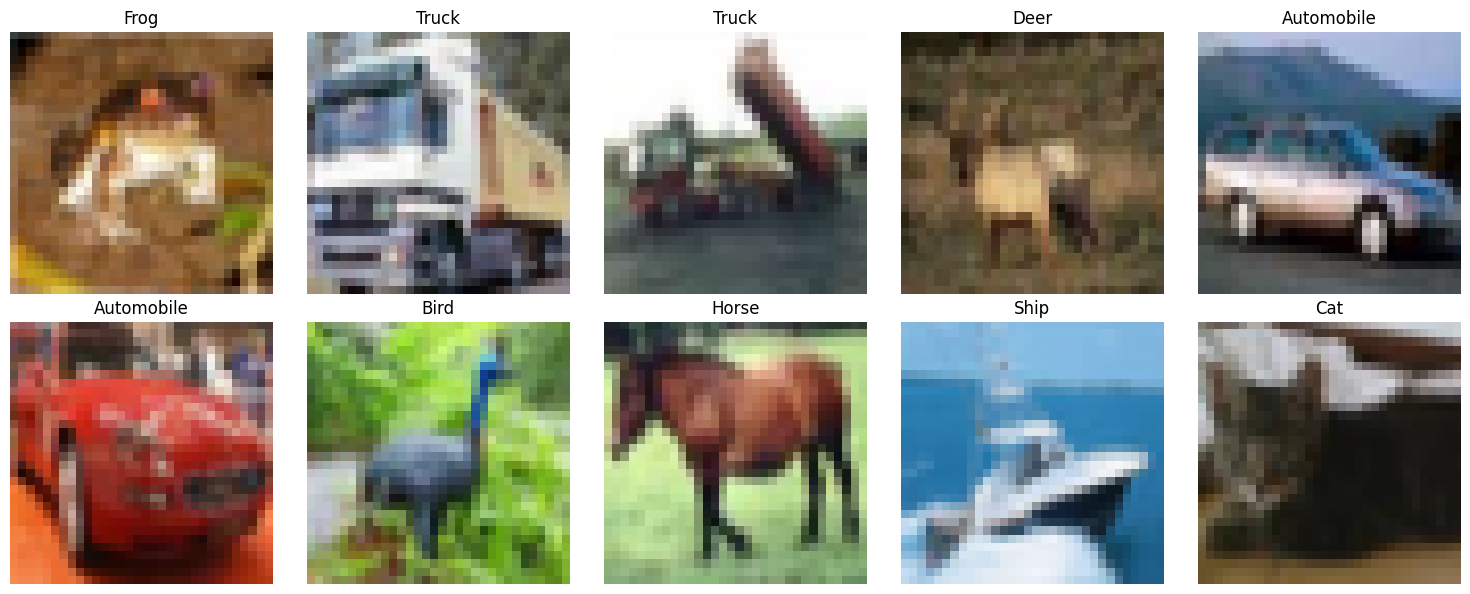

In [7]:
plt.figure(figsize=(15, 6))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")

plt.tight_layout()
plt.show()

### Normalize the Images

The pixel values in the CIFAR-10 images range from **0 to 255**. To improve the efficiency and stability of model training, the pixel values are normalized to the range **0 to 1** by dividing each pixel value by **255**.

In [8]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training Data Range :", X_train.min(), "to", X_train.max())
print("Testing Data Range  :", X_test.min(), "to", X_test.max())

Training Data Range : 0.0 to 1.0
Testing Data Range  : 0.0 to 1.0


#### Observation

The pixel values have been successfully normalized to the range **0 to 1**, making the dataset ready for model training.

## Phase 2: Artificial Neural Network (ANN)

### Artificial Neural Network (ANN)

- An Artificial Neural Network (ANN) is a deep learning model that learns patterns from input data using interconnected layers of neurons. In this assignment, the ANN is used to classify CIFAR-10 images.

- **Flatten Layer:** Converts the 32 × 32 × 3 image into a 1D vector so it can be processed by Dense layers.

- **Dense Layers (512, 256):** Learn complex patterns and relationships from the flattened input using the ReLU activation function.

- **Dropout Layers:** Randomly deactivate some neurons during training to reduce overfitting and improve generalization.

- **Output Layer (10 Neurons):** Uses the Softmax activation function to predict the probability of each of the 10 image classes.

### Build the ANN Model

In [9]:
ann_model = Sequential()
ann_model.add(Flatten(input_shape=(32, 32, 3)))
ann_model.add(Dense(512, activation='relu'))
ann_model.add(Dropout(0.5))
ann_model.add(Dense(256, activation='relu'))
ann_model.add(Dropout(0.3))
ann_model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Model Summary

In [10]:
ann_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,573,376 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,707,274 (6.51 MB)

 Trainable params: 1,707,274 (6.51 MB)

 Non-trainable params: 0 (0.00 B)

### Observation

- The ANN consists of one Flatten layer, two hidden Dense layers (512 and 256 neurons), two Dropout layers, and an output layer with 10 neurons.
- The model contains **1,707,274 trainable parameters**, indicating a high-capacity network capable of learning complex patterns from the input images.
- The Flatten layer has **0 parameters** because it only reshapes the input, while the Dense layers contribute most of the trainable parameters.

### Compile the ANN Model

### Model Compilation

#### Optimizer (Adam)

- **Definition:** An optimizer is an algorithm that updates the model's weights during training to minimize the loss function.

- **Reason for Using Adam:** Adam automatically adjusts the learning rate for each parameter, resulting in faster convergence and more stable training.

#### Loss Function (Sparse Categorical Crossentropy)

- **Definition:** A loss function measures the difference between the model's predicted output and the actual target values.

- **Reason for Using Sparse Categorical Crossentropy:** It is suitable for multi-class classification problems where the class labels are provided as integer values (0–9) instead of one-hot encoded vectors.

#### Evaluation Metric (Accuracy)

- **Definition:** An evaluation metric is used to measure the performance of the model during training and testing.

- **Reason for Using Accuracy:** Accuracy calculates the percentage of correctly classified images, making it an appropriate metric for comparing classification models.

In [11]:
ann_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Train the ANN Model

### Training Parameters

- **Epochs:** One complete pass of the entire training dataset through the model.

- **Batch Size:** The number of training samples processed before updating the model's weights.

- **Validation Split:** The fraction of the training data reserved for validating the model after each epoch.

In [12]:
ann_history = ann_model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.1826 - loss: 2.1663 - val_accuracy: 0.2422 - val_loss: 2.0292
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.2099 - loss: 2.0748 - val_accuracy: 0.2542 - val_loss: 2.0259
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2163 - loss: 2.0490 - val_accuracy: 0.2798 - val_loss: 1.9762
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2235 - loss: 2.0378 - val_accuracy: 0.2685 - val_loss: 2.0275
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.2234 - loss: 2.0384 - val_accuracy: 0.2526 - val_loss: 2.0272
Epoch 6/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2329 - loss: 2.0271 - val_accuracy: 0.2709 - val_loss: 1.9892
Epoch 7/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.2295 - loss: 2.0253 - val_accuracy: 0.2901 - val_loss: 2.0174
Epoch 8/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.2375 - loss: 2.0163 - 

### Observation

- The training accuracy gradually increased over the 10 epochs, indicating that the ANN was learning from the training data.
- The validation accuracy also showed a gradual improvement, suggesting that the model was able to generalize to unseen data without significant overfitting.
- Despite the improvement, the ANN achieved relatively low accuracy, highlighting the limitations of using fully connected networks for image classification.

### Evaluate the ANN Model

In [13]:
ann_test_loss, ann_test_accuracy = ann_model.evaluate(X_test, y_test)

print(f"Test Loss: {ann_test_loss:.4f}")
print(f"Test Accuracy: {ann_test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.2979 - loss: 1.9800
Test Loss: 1.9800
Test Accuracy: 0.2979


### Observation

- The model achieved a **test accuracy of 27.97%** with a **test loss of 1.9800** on the unseen test dataset.
- The relatively low test accuracy indicates that the ANN was not able to capture spatial features effectively from the images.
- This highlights the need for CNNs, which are better suited for image classification tasks due to their ability to learn local patterns and spatial relationships.

## Phase 3: Build a Convolutional Neural Network (CNN)

### Convolutional Neural Network (CNN)

- A Convolutional Neural Network (CNN) is a deep learning model specially designed for image data that learns spatial features such as edges, textures, and patterns.

- **Conv2D Layer:** Applies filters to the input image to extract important features.

- **Batch Normalization Layer:** Normalizes the outputs of the previous layer, making training faster and more stable.

- **MaxPooling2D Layer:** Reduces the spatial dimensions of the feature maps while retaining the most important information.

- **Flatten Layer:** Converts the extracted feature maps into a 1D vector for the Dense layers.

- **Dense Layer:** Learns high-level patterns from the extracted features before classification.

- **Dropout Layer:** Randomly deactivates some neurons during training to reduce overfitting.

- **Output Layer (10 Neurons):** Uses the Softmax activation function to predict the probability of each of the 10 image classes.

### Build the CNN Architecture

In [14]:
from tensorflow.keras import models, layers

cnn_model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### CNN Model Summary

In [15]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 357,194 (1.36 MB)

 Trainable params: 357,002 (1.36 MB)

 Non-trainable params: 192 (768.00 B)

### Observation

- The CNN consists of three convolutional blocks with **32, 64, and 128 filters**, followed by Batch Normalization, MaxPooling, Flatten, Dense, Dropout, and an output layer.
- The model contains **357,002 trainable parameters** and **192 non-trainable parameters**, where the non-trainable parameters come from the Batch Normalization layers.
- The number of filters increases as the network goes deeper, while MaxPooling gradually reduces the spatial dimensions, enabling the model to learn richer and more complex image features.

### Compile the CNN Model

In [16]:
# Compile the CNN model
cnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

### Train the CNN Model

In [17]:
cnn_history = cnn_model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_split=0.1,
    batch_size=64
)

Epoch 1/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 14s 11ms/step - accuracy: 0.4667 - loss: 1.4916 - val_accuracy: 0.5148 - val_loss: 1.3508
Epoch 2/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.6083 - loss: 1.1207 - val_accuracy: 0.6270 - val_loss: 1.0683
Epoch 3/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.6721 - loss: 0.9449 - val_accuracy: 0.6528 - val_loss: 1.0007
Epoch 4/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7102 - loss: 0.8341 - val_accuracy: 0.6848 - val_loss: 0.9255
Epoch 5/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7431 - loss: 0.7425 - val_accuracy: 0.6898 - val_loss: 0.9446
Epoch 6/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7666 - loss: 0.6645 - val_accuracy: 0.7226 - val_loss: 0.8125
Epoch 7/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7907 - loss: 0.5976 - val_accuracy: 0.6902 - val_loss: 0.9945
Epoch 8/10
704/704 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8078 - loss: 0.5465 - val_accuracy:

### Observation

- The training accuracy and validation accuracy improved consistently over the 10 epochs, indicating that the CNN learned meaningful image features.
- The training and validation loss gradually decreased, showing that the model was effectively optimizing its predictions.
- Compared to the ANN, the CNN achieved significantly better performance by preserving spatial information through convolution and pooling operations.

### Evaluate the CNN Model

In [18]:
cnn_test_loss, cnn_test_accuracy = cnn_model.evaluate(X_test, y_test)

print(f"Test Loss: {cnn_test_loss:.4f}")
print(f"Test Accuracy: {cnn_test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7120 - loss: 0.9715
Test Loss: 0.9715
Test Accuracy: 0.7120


### Observation

- The CNN achieved a **test accuracy of 71.20%** with a **test loss of 0.9715** on the unseen test dataset.
- The significantly higher test accuracy compared to the ANN demonstrates that CNNs are more effective for image classification tasks.
- The lower test loss indicates that the CNN made more accurate predictions and generalized well to unseen images.

### Compare ANN and CNN Validation Accuracy

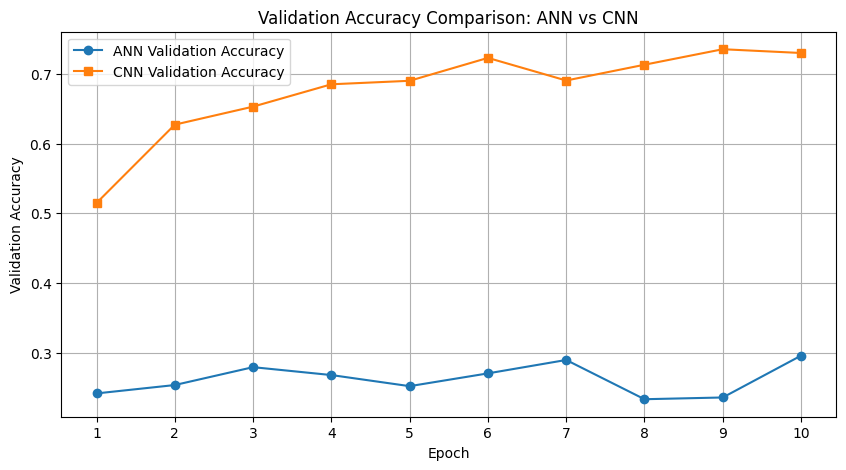

In [19]:
epochs = range(1, len(ann_history.history['val_accuracy']) + 1)

plt.figure(figsize=(10,5))

plt.plot(epochs, ann_history.history['val_accuracy'],
         marker='o', label='ANN Validation Accuracy')

plt.plot(epochs, cnn_history.history['val_accuracy'],
         marker='s', label='CNN Validation Accuracy')

plt.title("Validation Accuracy Comparison: ANN vs CNN")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.xticks(epochs)
plt.grid(True)
plt.legend()

plt.show()

### Observation

- The CNN consistently achieved higher validation accuracy than the ANN across all 10 epochs.
- The CNN's validation accuracy improved steadily from approximately **51%** to **73%**, indicating effective learning and better generalization.
- The ANN showed only a slight improvement in validation accuracy, remaining below **30%** throughout training.
- The significant performance gap demonstrates that CNNs are more suitable for image classification tasks because they preserve and learn spatial features from images.

### Compare ANN and CNN Performance

In [20]:
comparison_df = pd.DataFrame({
    "Model": ["ANN", "CNN"],
    "Test Accuracy": [ann_test_accuracy, cnn_test_accuracy],
    "Test Loss": [ann_test_loss, cnn_test_loss]
})

comparison_df

,Model,Test Accuracy,Test Loss
0,ANN,0.2979,1.979985
1,CNN,0.7120,0.971523


### Observation

- The CNN achieved significantly higher test accuracy (**71.20%**) than the ANN (**29.79%**), demonstrating its superior performance on image classification tasks.
- The primary reason for this difference is that the ANN flattens the input image, losing important spatial information, whereas the CNN preserves spatial relationships through convolution and pooling operations.
- By learning local features such as edges, textures, and shapes, the CNN extracts more meaningful image representations, resulting in better classification performance.

### Data Augmentation

- **Data Augmentation:** A technique that creates modified versions of training images to increase data diversity and improve the model's ability to generalize.

- **Input Layer:** Specifies the input image shape as **32 × 32 × 3** before applying augmentation.

- **RandomFlip:** Randomly flips images horizontally during training to make the model invariant to image orientation.

- **RandomRotation:** Randomly rotates images by a small angle to improve the model's robustness to different viewing angles.

- **RandomZoom:** Randomly zooms images in or out to help the model recognize objects at different scales.

In [21]:
data_augmentation = tf.keras.Sequential([
    layers.Input(shape=(32, 32, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

### Build the Enhanced Data-Augmented CNN Model

In [22]:
augmented_cnn_model = models.Sequential([
    data_augmentation,

    # Convolution Layers
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),

    # Classifier
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

### Model Summary

In [23]:
augmented_cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 652,362 (2.49 MB)

 Trainable params: 652,170 (2.49 MB)

 Non-trainable params: 192 (768.00 B)

### Observation

- The enhanced CNN includes a **Data Augmentation** layer before the convolutional layers to improve the model's ability to generalize to unseen images.
- The Dense layer configuration was expanded from **128 neurons** to **256 → 128 neurons**, increasing the model's learning capacity.
- The model contains **652,170 trainable parameters**, which is higher than the baseline CNN due to the additional Dense layer and increased number of neurons.
- The overall CNN architecture remains unchanged, while the added regularization and increased model capacity aim to improve classification performance and reduce overfitting.

### Compile the Enhanced CNN Model

In [24]:
augmented_cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Configure Early Stopping

## Early Stopping

- **Early Stopping:** A callback that automatically stops training when the model's performance on the validation data stops improving, helping to prevent overfitting.

- **Monitor (`val_loss`):** Specifies that the validation loss will be tracked to determine when training should stop.

- **Patience (`patience=3`):** Allows the model to continue training for **3 additional epochs** after the last improvement before stopping.

- **Restore Best Weights (`restore_best_weights=True`):** Restores the model weights from the epoch with the lowest validation loss after training stops.

In [25]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

### Train the Enhanced CNN Model with Data Augmentation and Early Stopping

In [26]:
augmented_history = augmented_cnn_model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping]
)

Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.3840 - loss: 1.7117 - val_accuracy: 0.4046 - val_loss: 1.6743
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.4900 - loss: 1.4295 - val_accuracy: 0.5392 - val_loss: 1.3688
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5358 - loss: 1.3187 - val_accuracy: 0.5452 - val_loss: 1.2980
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5711 - loss: 1.2331 - val_accuracy: 0.5618 - val_loss: 1.2556
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5918 - loss: 1.1796 - val_accuracy: 0.6052 - val_loss: 1.1327
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6108 - loss: 1.1283 - val_accuracy: 0.5912 - val_loss: 1.1415
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6243 - loss: 1.0962 - val_accuracy: 0.6366 - val_loss: 1.0686
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.6353 - loss: 1.0647 - val_ac

### Observation

- The training and validation accuracy improved steadily during training, indicating that the enhanced CNN successfully learned meaningful image features.
- Data augmentation exposed the model to varied versions of the training images, helping improve its ability to generalize to unseen data.
- Although the model was configured to train for **20 epochs**, the **EarlyStopping** callback terminated training early once the validation loss stopped improving, preventing unnecessary training and reducing the risk of overfitting.

### Verification of EarlyStopping

- The following cells were used to verify that the EarlyStopping callback was triggered successfully and that the best model was retained.

In [30]:
print(len(augmented_history.history["loss"]))
print(augmented_history.history["val_loss"])

13
[1.6743415594100952, 1.3688459396362305, 1.2980122566223145, 1.2556296586990356, 1.1326904296875, 1.1414533853530884, 1.068556785583496, 1.0637400150299072, 1.0226298570632935, 0.8716793060302734, 0.9902839064598083, 0.8718395233154297, 0.8757709264755249]


### Model Evaluation

In [33]:
augmented_test_loss, augmented_test_accuracy = augmented_cnn_model.evaluate(
    X_test, y_test
)

print(f"Test Loss: {augmented_test_loss:.4f}")
print(f"Test Accuracy: {augmented_test_accuracy:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6899 - loss: 0.9044
Test Loss: 0.9044
Test Accuracy: 0.6899


### Observation

- The enhanced CNN achieved a **test accuracy of 68.99%** with a **test loss of 0.9044** on the unseen test dataset.
- The model successfully applied **data augmentation** and **EarlyStopping**, helping improve generalization while reducing the risk of overfitting.
- EarlyStopping terminated training after **13 epochs** instead of the planned **20 epochs**, preventing unnecessary training once the validation loss stopped improving.

In [34]:
print("Stopped epoch:", early_stopping.stopped_epoch)

Stopped epoch: 12


### Final Model Performance Comparison

In [35]:
final_comparison_df = pd.DataFrame({
    "Model": [
        "ANN",
        "Baseline CNN",
        "Enhanced CNN"
    ],
    "Test Accuracy": [
        ann_test_accuracy,
        cnn_test_accuracy,
        augmented_test_accuracy
    ],
    "Test Loss": [
        ann_test_loss,
        cnn_test_loss,
        augmented_test_loss
    ]
})

final_comparison_df

,Model,Test Accuracy,Test Loss
0,ANN,0.2979,1.979985
1,Baseline CNN,0.7120,0.971523
2,Enhanced CNN,0.6899,0.904413


### Observation

- The ANN achieved the lowest test accuracy, confirming that fully connected networks are less effective for image classification tasks.
- The Baseline CNN achieved the highest test accuracy (**71.20%**), demonstrating the effectiveness of convolutional layers in learning spatial features from images.
- The Enhanced CNN achieved a comparable test accuracy (**68.99%**) with the lowest test loss (**0.9044**), indicating stable predictions despite stronger regularization.
- The slight reduction in test accuracy may be due to the effects of data augmentation and EarlyStopping, which prioritize better generalization and reduced overfitting rather than maximizing accuracy on a single training run.

## Conclusion
- Successfully implemented image classification on the CIFAR-10 dataset using both Artificial Neural Network (ANN) and Convolutional Neural Network (CNN) architectures.

- Normalized the image pixel values from the range **0–255** to **0–1**, resulting in more stable and efficient model training.

- Developed a multi-layer ANN with Dense and Dropout layers. Although the network capacity was increased, the ANN achieved lower accuracy because flattening the images removed important spatial information.

- Built a CNN using **Conv2D**, **BatchNormalization**, **MaxPooling2D**, **Flatten**, **Dense**, and **Dropout** layers, enabling the model to learn meaningful spatial features such as edges, textures, and object patterns.

- Observed that the CNN significantly outperformed the ANN, demonstrating the effectiveness of convolutional networks for image classification tasks.

- Enhanced the CNN by incorporating **data augmentation** techniques (RandomFlip, RandomRotation, and RandomZoom) to improve the model's ability to generalize to unseen images.

- Applied the **EarlyStopping** callback to monitor validation loss, helping prevent unnecessary training and reducing the risk of overfitting by restoring the best model weights.

- Completed all required beginner tasks, including increasing the ANN architecture, using CNN filters of **32 → 64 → 128**, training for up to **20 epochs**, implementing **EarlyStopping**, and training an enhanced CNN with **data augmentation**.

- Overall, this assignment demonstrated the importance of proper preprocessing, deep learning architecture design, and regularization techniques in building effective image classification models.